# Food Freshness Dataset: Strawberry Augmentation with PyTorch

This notebook prepares a leakage-safe image dataset for food freshness classification.

Workflow:

1. Download the dataset from Google Drive using `gdown`.
2. Inspect the original class distribution.
3. Split the original images into `train`, `val`, and `test` first.
4. Copy the clean split dataset into a new folder.
5. Augment only the strawberry classes inside the training split:
   - `FreshStrawberry`
   - `RottenStrawberry`
6. Visualize the distribution before splitting, after splitting, and after augmentation.
7. Save the augmented dataset as a folder and a `.zip` file.

The validation and test sets are never augmented. This avoids data leakage: augmented versions of a training image cannot appear in validation or test.

In [1]:
# Colab setup
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown", "tqdm"])


0

In [2]:
from pathlib import Path
from collections import Counter
import math
import random
import shutil
import zipfile

import gdown
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DRIVE_URL = "https://drive.google.com/uc?id=1y01ZDbHVh6qFJq6upA4pEVIjEC8T0xuD"
ZIP_PATH = Path("food_freshness_dataset.zip")
EXTRACT_DIR = Path("raw_data")
SOURCE_DIR = EXTRACT_DIR / "Food Freshness Dataset"

OUTPUT_DIR = Path("Food_Freshness_Dataset_Split_Augmented")
OUTPUT_ZIP = Path("Food_Freshness_Dataset_Split_Augmented.zip")

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# If None, strawberry train classes are augmented up to the smallest non-strawberry train class.
# You can replace None with an integer, for example 3000, if you want a fixed target.
TARGET_TRAIN_COUNT = None

STRAWBERRY_CLASSES = ["FreshStrawberry", "RottenStrawberry"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Torch version:", torch.__version__)
print("Output folder:", OUTPUT_DIR.resolve())

Torch version: 2.10.0+cpu
Output folder: /content/Food_Freshness_Dataset_Split_Augmented


## Download and extract the dataset

The code below downloads the dataset archive and extracts it into `raw_data/`.

In [3]:
if not ZIP_PATH.exists():
    gdown.download(DRIVE_URL, str(ZIP_PATH), quiet=False)
else:
    print(f"Using existing archive: {ZIP_PATH}")

if SOURCE_DIR.exists():
    print(f"Using existing extracted folder: {SOURCE_DIR}")
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print(f"Extracted to: {EXTRACT_DIR}")

if not SOURCE_DIR.exists():
    print("Available extracted folders:")
    for p in EXTRACT_DIR.iterdir():
        print("-", p)
    raise FileNotFoundError(f"Expected dataset folder not found: {SOURCE_DIR}")

Downloading...
From (original): https://drive.google.com/uc?id=1y01ZDbHVh6qFJq6upA4pEVIjEC8T0xuD
From (redirected): https://drive.google.com/uc?id=1y01ZDbHVh6qFJq6upA4pEVIjEC8T0xuD&confirm=t&uuid=ed9991ae-e60a-4ad9-aa71-d152519a9782
To: /content/food_freshness_dataset.zip
100%|██████████| 2.03G/2.03G [00:22<00:00, 90.5MB/s]


Extracted to: raw_data


## Discover classes and inspect the original imbalance

The original folder has two top-level freshness groups, `Fresh` and `Rotten`, and each class folder sits below those groups.

In [4]:
def is_image(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS

records = []
for freshness_dir in sorted([p for p in SOURCE_DIR.iterdir() if p.is_dir()]):
    for class_dir in sorted([p for p in freshness_dir.iterdir() if p.is_dir()]):
        class_name = class_dir.name
        for img_path in sorted(class_dir.rglob("*")):
            if is_image(img_path):
                records.append({
                    "source_path": str(img_path),
                    "freshness_group": freshness_dir.name,
                    "class_name": class_name,
                    "original_file_name": img_path.name,
                })

original_df = pd.DataFrame(records)
print(f"Total images: {len(original_df):,}")
print(f"Total classes: {original_df['class_name'].nunique()}")

original_counts = (
    original_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
    .sort_values("class_name")
)
original_counts

Total images: 16,837
Total classes: 6


,class_name,count
3,FreshApple,3431
2,FreshBanana,3473
4,FreshStrawberry,818
0,RottenApple,4437
1,RottenBanana,4038
5,RottenStrawberry,640


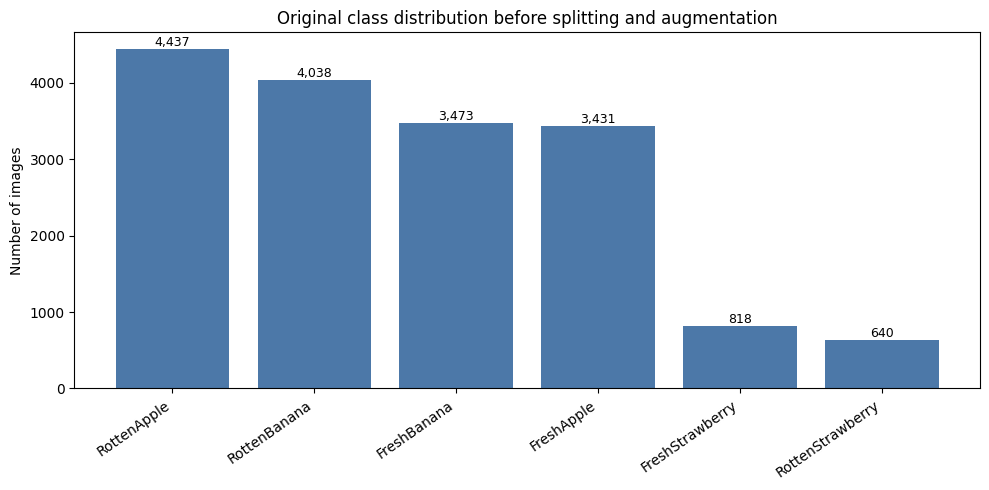

In [5]:
def plot_bar_counts(counts_df, x_col="class_name", y_col="count", title="Class distribution", color="#4C78A8"):
    ordered = counts_df.sort_values(y_col, ascending=False).copy()
    plt.figure(figsize=(10, 5))
    bars = plt.bar(ordered[x_col], ordered[y_col], color=color)
    plt.title(title)
    plt.ylabel("Number of images")
    plt.xticks(rotation=35, ha="right")
    for bar in bars:
        height = int(bar.get_height())
        plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:,}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_bar_counts(original_counts, title="Original class distribution before splitting and augmentation")

## Stratified train/validation/test split

The split below is stratified by construction: each class is shuffled separately, then divided into train, validation, and test portions.

No augmented image is created before this step.

In [6]:
def stratified_split_by_class(df, train_ratio=0.70, val_ratio=0.15, seed=42):
    rng = random.Random(seed)
    split_parts = []

    for class_name, class_df in df.groupby("class_name", sort=True):
        rows = class_df.to_dict("records")
        rng.shuffle(rows)

        n = len(rows)
        n_train = int(math.floor(n * train_ratio))
        n_val = int(math.floor(n * val_ratio))
        n_test = n - n_train - n_val

        for i, row in enumerate(rows):
            if i < n_train:
                split = "train"
            elif i < n_train + n_val:
                split = "val"
            else:
                split = "test"
            row = dict(row)
            row["split"] = split
            split_parts.append(row)

        print(f"{class_name:18s} total={n:5d} train={n_train:5d} val={n_val:4d} test={n_test:4d}")

    return pd.DataFrame(split_parts)

split_df = stratified_split_by_class(original_df, TRAIN_RATIO, VAL_RATIO, SEED)

split_counts = (
    split_df.groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
)

split_pivot = (
    split_counts.pivot(index="class_name", columns="split", values="count")
    .fillna(0)
    .astype(int)
)
split_pivot = split_pivot[["train", "val", "test"]]
split_pivot["total"] = split_pivot.sum(axis=1)
split_pivot

FreshApple         total= 3431 train= 2401 val= 514 test= 516
FreshBanana        total= 3473 train= 2431 val= 520 test= 522
FreshStrawberry    total=  818 train=  572 val= 122 test= 124
RottenApple        total= 4437 train= 3105 val= 665 test= 667
RottenBanana       total= 4038 train= 2826 val= 605 test= 607
RottenStrawberry   total=  640 train=  448 val=  96 test=  96


split,train,val,test,total
class_name,,,,
FreshApple,2401,514,516,3431
FreshBanana,2431,520,522,3473
FreshStrawberry,572,122,124,818
RottenApple,3105,665,667,4437
RottenBanana,2826,605,607,4038
RottenStrawberry,448,96,96,640


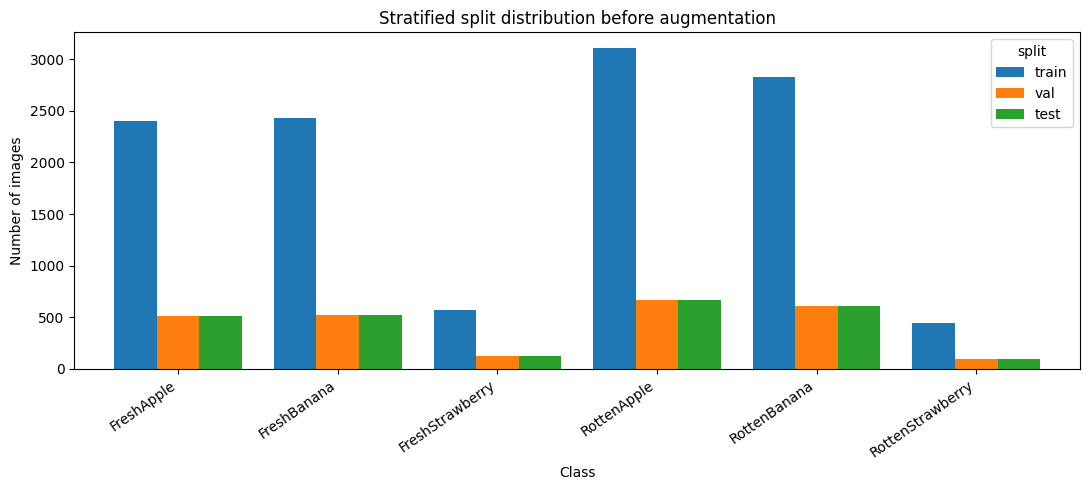

In [7]:
def plot_split_distribution(split_counts_df, title="Distribution by split"):
    pivot = (
        split_counts_df.pivot(index="class_name", columns="split", values="count")
        .fillna(0)
        .astype(int)
    )
    pivot = pivot[[c for c in ["train", "val", "test"] if c in pivot.columns]]

    ax = pivot.plot(kind="bar", figsize=(11, 5), width=0.8)
    ax.set_title(title)
    ax.set_ylabel("Number of images")
    ax.set_xlabel("Class")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

plot_split_distribution(split_counts, title="Stratified split distribution before augmentation")

## Copy the clean split dataset

This creates a new folder with the standard `ImageFolder` layout:

```text
Food_Freshness_Dataset_Split_Augmented/
├── train/
│   ├── FreshApple/
│   ├── FreshBanana/
│   ├── FreshStrawberry/
│   ├── RottenApple/
│   ├── RottenBanana/
│   └── RottenStrawberry/
├── val/
│   └── ...
└── test/
    └── ...
```

The copied files are renamed with a numeric prefix to avoid filename collisions.

In [8]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

copy_records = []
for row_id, row in tqdm(split_df.reset_index(drop=True).iterrows(), total=len(split_df), desc="Copying split files"):
    src = Path(row["source_path"])
    split = row["split"]
    class_name = row["class_name"]
    dest_dir = OUTPUT_DIR / split / class_name
    dest_dir.mkdir(parents=True, exist_ok=True)

    dest_name = f"orig_{row_id:06d}_{src.name}"
    dest = dest_dir / dest_name
    shutil.copy2(src, dest)

    copy_records.append({
        "source_path": str(src),
        "output_path": str(dest),
        "split": split,
        "class_name": class_name,
        "is_augmented": False,
    })

copy_df = pd.DataFrame(copy_records)
copy_df.to_csv(OUTPUT_DIR / "split_manifest_before_augmentation.csv", index=False)
print(f"Copied {len(copy_df):,} original images into {OUTPUT_DIR}")

Copying split files:   0%|          | 0/16837 [00:00<?, ?it/s]

Copied 16,837 original images into Food_Freshness_Dataset_Split_Augmented


## Augment only strawberry images in the training split

The augmentation target is computed from the training split. By default, each strawberry training class is expanded up to the smallest non-strawberry training class. This improves balance without letting synthetic data dominate the dataset.

You can set `TARGET_TRAIN_COUNT` to a fixed number if you want a different target.

In [9]:
def count_images_in_folder(dataset_dir: Path):
    rows = []
    for split_dir in sorted([p for p in dataset_dir.iterdir() if p.is_dir()]):
        split = split_dir.name
        for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
            count = sum(1 for p in class_dir.iterdir() if is_image(p))
            rows.append({"split": split, "class_name": class_dir.name, "count": count})
    return pd.DataFrame(rows)

before_aug_counts = count_images_in_folder(OUTPUT_DIR)
train_counts = before_aug_counts[before_aug_counts["split"] == "train"].set_index("class_name")["count"]

if TARGET_TRAIN_COUNT is None:
    non_strawberry_train_counts = train_counts.drop(labels=STRAWBERRY_CLASSES, errors="ignore")
    target_count = int(non_strawberry_train_counts.min())
else:
    target_count = int(TARGET_TRAIN_COUNT)

print("Training counts before augmentation:")
print(train_counts.sort_values(ascending=False))
print(f"\nTarget training count for each strawberry class: {target_count:,}")

Training counts before augmentation:
class_name
RottenApple         3105
RottenBanana        2826
FreshBanana         2431
FreshApple          2401
FreshStrawberry      572
RottenStrawberry     448
Name: count, dtype: int64

Target training count for each strawberry class: 2,401


In [10]:
IMG_SIZE = 224

augmentation_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.20, hue=0.03)
    ], p=0.75),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.92, 1.08), shear=5),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))], p=0.20),
])

# Mild transforms are used because the freshness signal can depend on visual texture and color.
# Vertical flips are avoided because they can create less natural fruit orientations.

In [11]:
def load_rgb(path: Path):
    with Image.open(path) as img:
        return img.convert("RGB")

def augment_class_to_target(class_name: str, target_count: int):
    class_dir = OUTPUT_DIR / "train" / class_name
    image_paths = sorted([p for p in class_dir.iterdir() if is_image(p) and not p.name.startswith("aug_")])
    current_count = len([p for p in class_dir.iterdir() if is_image(p)])
    needed = max(0, target_count - current_count)

    print(f"{class_name}: current={current_count:,}, target={target_count:,}, augmenting={needed:,}")
    if needed == 0:
        return []

    new_records = []
    for i in tqdm(range(needed), desc=f"Augmenting {class_name}"):
        src = image_paths[i % len(image_paths)]
        img = load_rgb(src)
        aug_img = augmentation_transform(img)

        dest = class_dir / f"aug_{class_name}_{i:06d}_from_{src.stem}.jpg"
        aug_img.save(dest, quality=95)

        new_records.append({
            "source_path": str(src),
            "output_path": str(dest),
            "split": "train",
            "class_name": class_name,
            "is_augmented": True,
        })

    return new_records

aug_records = []
for class_name in STRAWBERRY_CLASSES:
    aug_records.extend(augment_class_to_target(class_name, target_count))

aug_df = pd.DataFrame(aug_records)
manifest_df = pd.concat([copy_df, aug_df], ignore_index=True)
manifest_df.to_csv(OUTPUT_DIR / "split_manifest_after_augmentation.csv", index=False)
print(f"Created {len(aug_df):,} augmented strawberry training images.")

FreshStrawberry: current=572, target=2,401, augmenting=1,829


Augmenting FreshStrawberry:   0%|          | 0/1829 [00:00<?, ?it/s]

RottenStrawberry: current=448, target=2,401, augmenting=1,953


Augmenting RottenStrawberry:   0%|          | 0/1953 [00:00<?, ?it/s]

Created 3,782 augmented strawberry training images.


## Check the distribution after augmentation

The validation and test splits should remain exactly the same. Only the strawberry classes in `train` should increase.

In [12]:
after_aug_counts = count_images_in_folder(OUTPUT_DIR)
after_aug_pivot = (
    after_aug_counts.pivot(index="class_name", columns="split", values="count")
    .fillna(0)
    .astype(int)
)
after_aug_pivot = after_aug_pivot[["train", "val", "test"]]
after_aug_pivot["total"] = after_aug_pivot.sum(axis=1)
after_aug_pivot

split,train,val,test,total
class_name,,,,
FreshApple,2401,514,516,3431
FreshBanana,2431,520,522,3473
FreshStrawberry,2401,122,124,2647
RottenApple,3105,665,667,4437
RottenBanana,2826,605,607,4038
RottenStrawberry,2401,96,96,2593


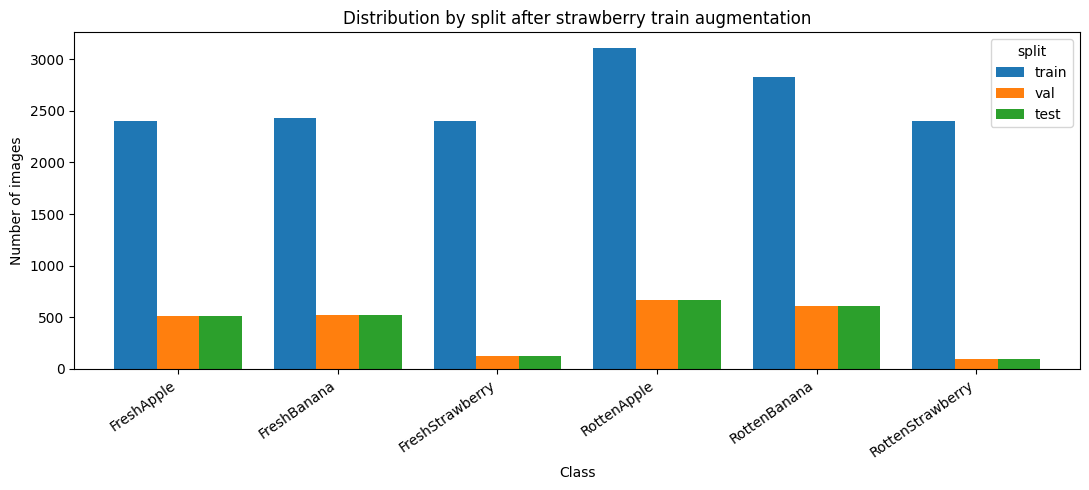

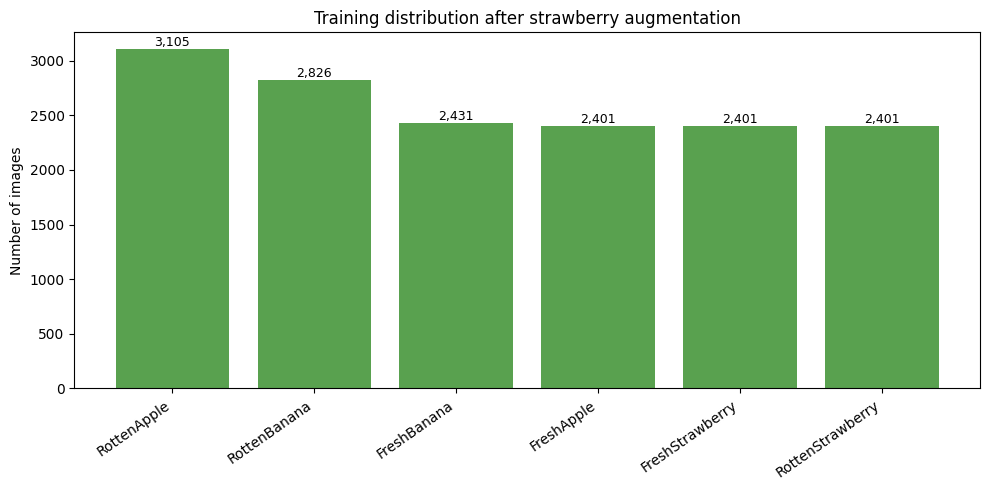

In [13]:
plot_split_distribution(after_aug_counts, title="Distribution by split after strawberry train augmentation")

train_after = after_aug_counts[after_aug_counts["split"] == "train"].copy()
plot_bar_counts(train_after, title="Training distribution after strawberry augmentation", color="#59A14F")

In [14]:
# Leakage-safety check: no augmented files should appear in val or test.
val_test_augmented = []
for split in ["val", "test"]:
    split_dir = OUTPUT_DIR / split
    for p in split_dir.rglob("aug_*"):
        if is_image(p):
            val_test_augmented.append(p)

assert len(val_test_augmented) == 0, "Augmented files were found in validation or test split."
print("Passed: no augmented files found in validation or test.")

# Original validation and test counts should match before and after augmentation.
before_val_test = before_aug_counts[before_aug_counts["split"].isin(["val", "test"])].sort_values(["split", "class_name"]).reset_index(drop=True)
after_val_test = after_aug_counts[after_aug_counts["split"].isin(["val", "test"])].sort_values(["split", "class_name"]).reset_index(drop=True)
pd.testing.assert_frame_equal(before_val_test, after_val_test)
print("Passed: validation and test distributions are unchanged after augmentation.")

Passed: no augmented files found in validation or test.
Passed: validation and test distributions are unchanged after augmentation.


## Show sample augmented strawberry images

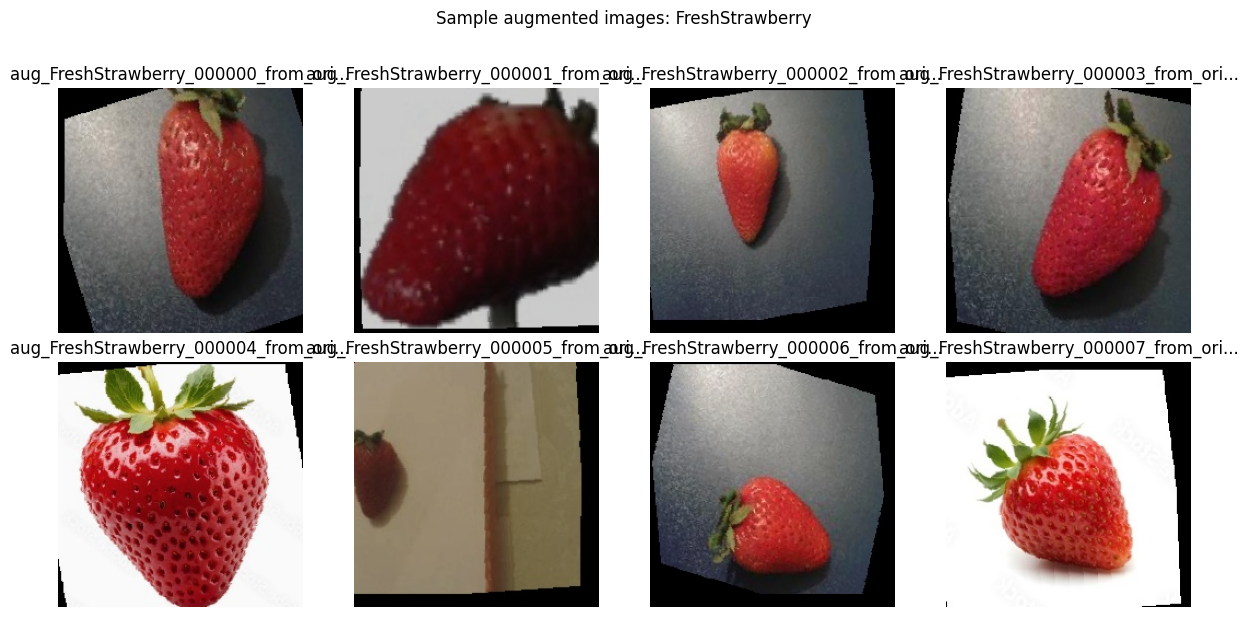

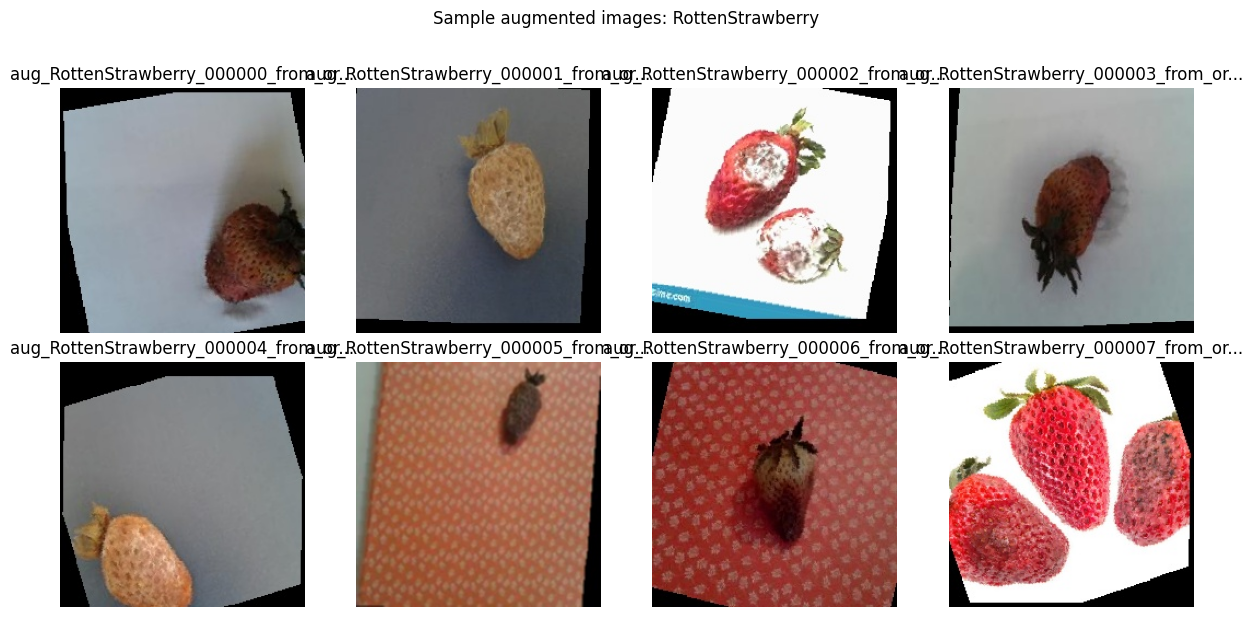

In [15]:
def show_sample_images(class_name, n=8):
    class_dir = OUTPUT_DIR / "train" / class_name
    aug_paths = sorted(class_dir.glob("aug_*.jpg"))[:n]
    if not aug_paths:
        print(f"No augmented images found for {class_name}.")
        return

    cols = 4
    rows = math.ceil(len(aug_paths) / cols)
    plt.figure(figsize=(12, 3 * rows))
    for i, path in enumerate(aug_paths, start=1):
        img = Image.open(path).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(path.name[:35] + "...")
        plt.axis("off")
    plt.suptitle(f"Sample augmented images: {class_name}", y=1.02)
    plt.tight_layout()
    plt.show()

show_sample_images("FreshStrawberry", n=8)
show_sample_images("RottenStrawberry", n=8)

## Save the augmented dataset

The prepared dataset folder is saved as a zip file. In Colab, you can download the zip from the file browser or copy it to Google Drive.

In [16]:
if OUTPUT_ZIP.exists():
    OUTPUT_ZIP.unlink()

archive_base = str(OUTPUT_ZIP.with_suffix(""))
shutil.make_archive(archive_base, "zip", root_dir=OUTPUT_DIR)

print(f"Saved folder: {OUTPUT_DIR.resolve()}")
print(f"Saved zip:    {OUTPUT_ZIP.resolve()}")
print(f"Zip size:     {OUTPUT_ZIP.stat().st_size / (1024 ** 2):.2f} MB")

Saved folder: /content/Food_Freshness_Dataset_Split_Augmented
Saved zip:    /content/Food_Freshness_Dataset_Split_Augmented.zip
Zip size:     1991.72 MB


## Optional: copy the zip to Google Drive

Run this cell only if you want to save the augmented dataset into your own Google Drive.

In [19]:
from google.colab import drive
drive.mount('/content/drive')
shutil.copy2(OUTPUT_ZIP, Path('/content/drive/MyDrive/capstone') / OUTPUT_ZIP.name)

Mounted at /content/drive


PosixPath('/content/drive/MyDrive/capstone/Food_Freshness_Dataset_Split_Augmented.zip')